In [53]:
import numpy as np
import pandas as pd

In [54]:
suffix = "_filtered_hsc"
bc = pd.read_csv(f"/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed{suffix}/barcodes.csv", index_col=0).iloc[:, 0]
timepoints = pd.read_csv(f"/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed{suffix}/timepoints.csv", index_col=0).iloc[:, 0]
celltypes = pd.read_csv(f"/vast/projects/Sisseq/human-haematopoiesis-sis-seq/data/preprocessed{suffix}/celltypes.csv", index_col=0).iloc[:, 0]

In [55]:
rna_variance = 0.8
rna_variance_str = f"{rna_variance:.2f}"

In [56]:
X_rna = pd.read_csv(f"../data/preprocessed{suffix}/X_rna_variance_{rna_variance_str}.csv", index_col=0)
X_adt = pd.read_csv(f"../data/preprocessed{suffix}/X_adt.csv", index_col=0)
X_bc = np.load(f"../data/preprocessed{suffix}/X_bc.npy")

In [57]:
X_rna.shape, X_bc.shape, X_adt.shape

((112, 4787), (112, 5, 8), (112, 163))

In [58]:
X_rna = X_rna.div(X_rna.sum(axis=1), axis=0) * 1e4
X_rna = np.log1p(X_rna) # log normalise from prev code
X_adt = X_rna.div(X_adt.sum(axis=1), axis=0) * 1e4
X_adt = np.log1p(X_adt) # log normalise from prev code

In [59]:
import pandas as pd

print(pd.DataFrame({
    "celltype": celltypes,
    "timepoint": timepoints
}).value_counts())

celltype  timepoint
Lymph     D10          1
Mast      D17          1
Rest      D14          1
cDC1      D7           1
cDC2      D21          1
Name: count, dtype: int64


In [60]:
print(pd.Series(celltypes).value_counts().head())
print(pd.Series(timepoints).value_counts().head())

0
cDC1     1
Lymph    1
Rest     1
Mast     1
cDC2     1
Name: count, dtype: int64
0
D7     1
D10    1
D14    1
D17    1
D21    1
Name: count, dtype: int64


In [61]:
## zero variance breaking mofa
def remove_zero_var(X):
    return X.loc[:, X.var(axis=0) > 0]

X_rna = remove_zero_var(X_rna)
X_adt = remove_zero_var(X_adt)

In [62]:
data = [
    [X_rna.values],
    [X_adt.values],
    [X_bc.reshape(112, -1)]
]

In [63]:
from mofapy2.run.entry_point import entry_point

ent = entry_point()

ent.set_data_matrix(
    data,
    likelihoods=["gaussian", "gaussian", "gaussian"],
    views_names=["rna", "adt", "lineage"]
)

ent.set_model_options(factors=21)

ent.set_train_options(iter=3000, seed=42)

ent.build()
ent.run()


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Features names not provided, using default naming convention:
- feature1_view1, featureD_viewM

Groups names not provided, using default naming convention:
- group1, group2, ..., groupG

Samples names not provided, using default naming convention:
- sample1_group1, sample2_group1, sample1_group2, ..., sampleN_groupG

Successfully loaded view='rna' group='group0' with N=112 samples and D=4674 features...
Successfully loaded view='adt' group='group0' with N=112 samples and D=4674 features...
Successfully loaded view='lineage' group='group0' with N=112 samples and D=40 features...


Model options:
- Automatic Relevance Determination prior on the factors: False
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (rna): gaussian
- View 1 (adt): gaussian
- View 2 (lineage): gaussian




######################################
## Training the model with seed 42 ##
#########

In [64]:
Z = ent.model.getExpectations()["Z"]["E"]
W = ent.model.getExpectations()["W"]

W_lineage = W[2]["E"]  # lineage view

In [65]:
Z.shape

(112, 21)

In [66]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5)
modules = kmeans.fit_predict(W_lineage)

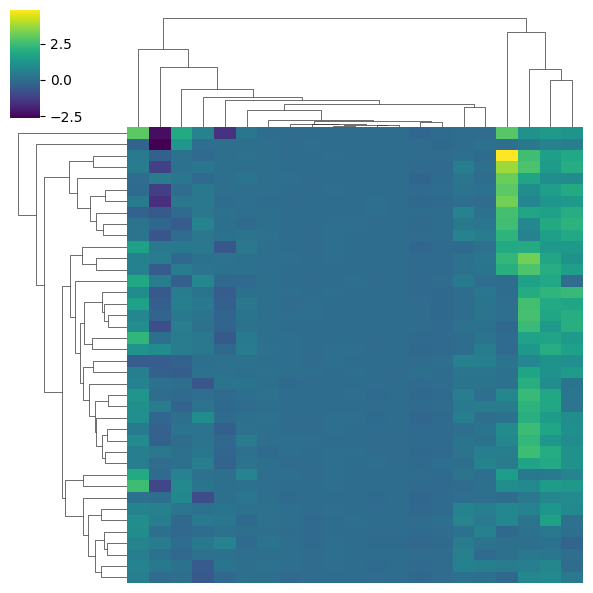

In [67]:
W = ent.model.getExpectations()["W"]
W_lineage = W[2]["E"]   # lineage view
from sklearn.cluster import KMeans
import seaborn as sb

kmeans = KMeans(n_clusters=5, random_state=0)
modules = kmeans.fit_predict(W_lineage)
order = np.argsort(modules)
W_sorted = W_lineage[order, :]
sb.clustermap(
    W_sorted,
    cmap="viridis",
    figsize=(6, 6),
    yticklabels=False,
    xticklabels=False
)

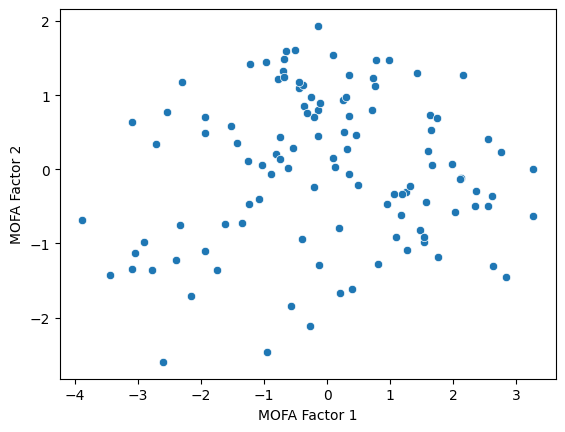

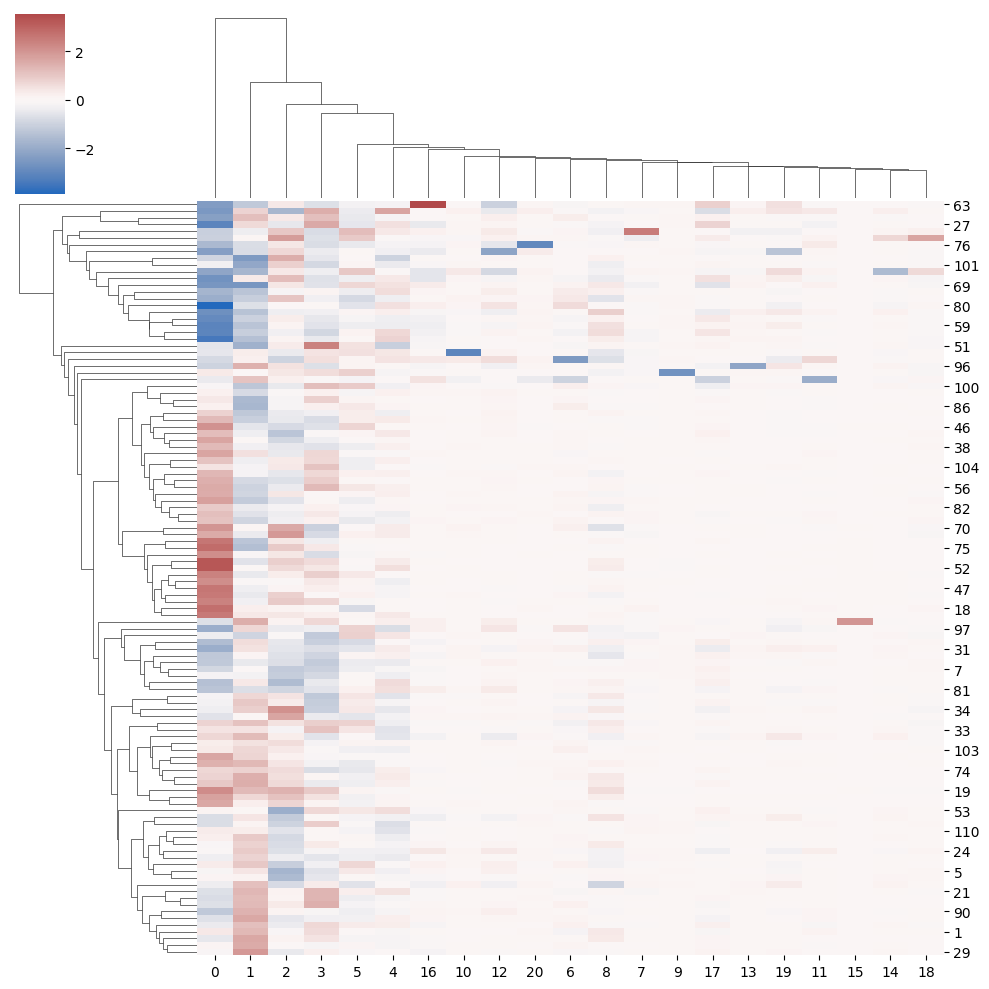

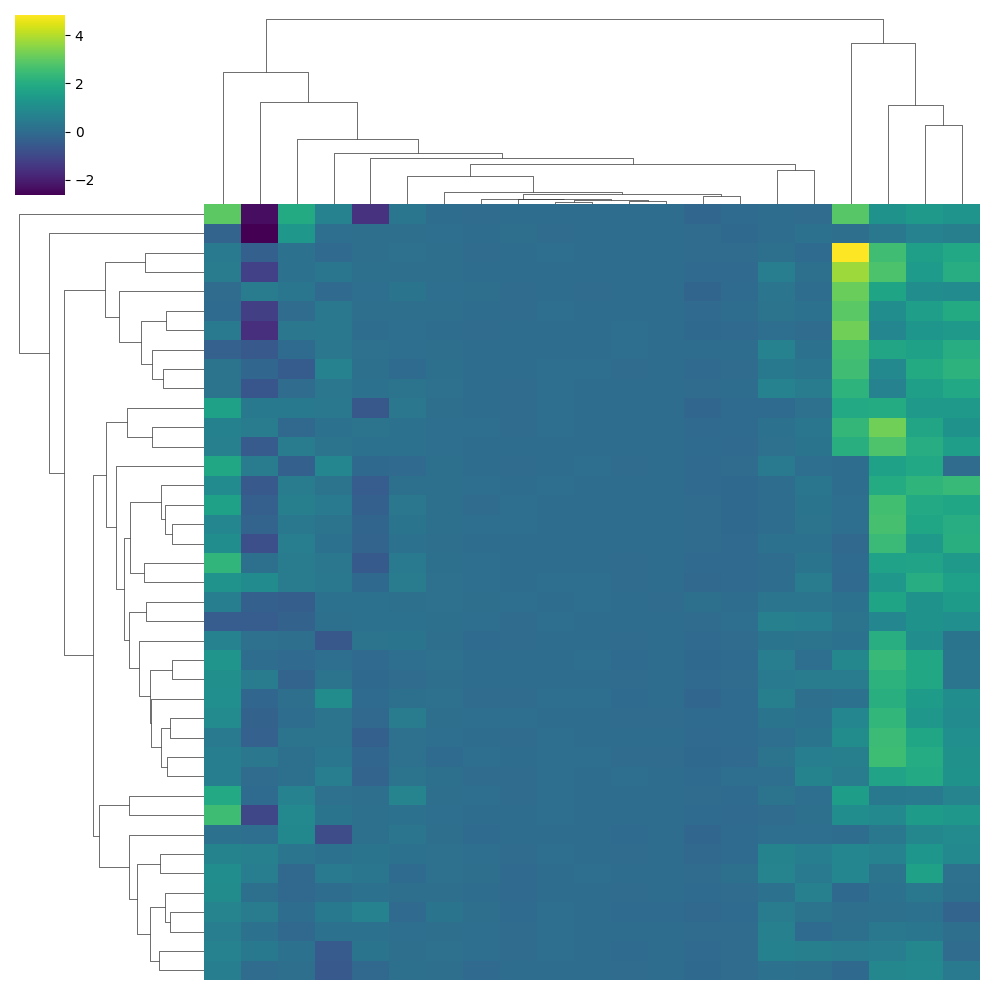

In [68]:
X_lineage = X_bc.reshape(X_bc.shape[0], -1)
Z = ent.model.getExpectations()["Z"]["E"]

import seaborn as sb
import matplotlib.pyplot as plt

sb.scatterplot(
    x=Z[:, 0],
    y=Z[:, 1]
)

plt.xlabel("MOFA Factor 1")
plt.ylabel("MOFA Factor 2")
sb.clustermap(
    Z,
    cmap="vlag",
    center=0
)
W = ent.model.getExpectations()["W"]
W_lineage = W[2]["E"]   # BC view

sb.clustermap(
    W_lineage,
    cmap="viridis",
    xticklabels=False,
    yticklabels=False
)

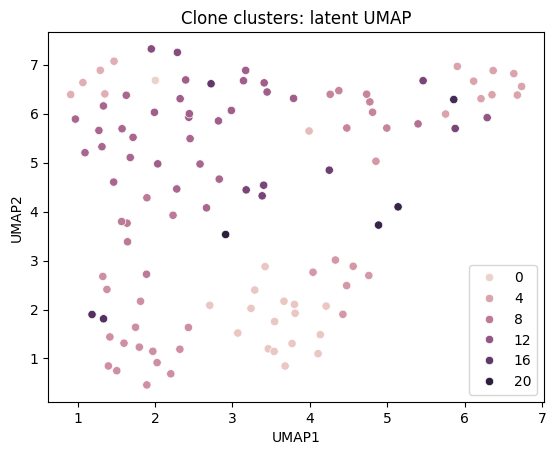

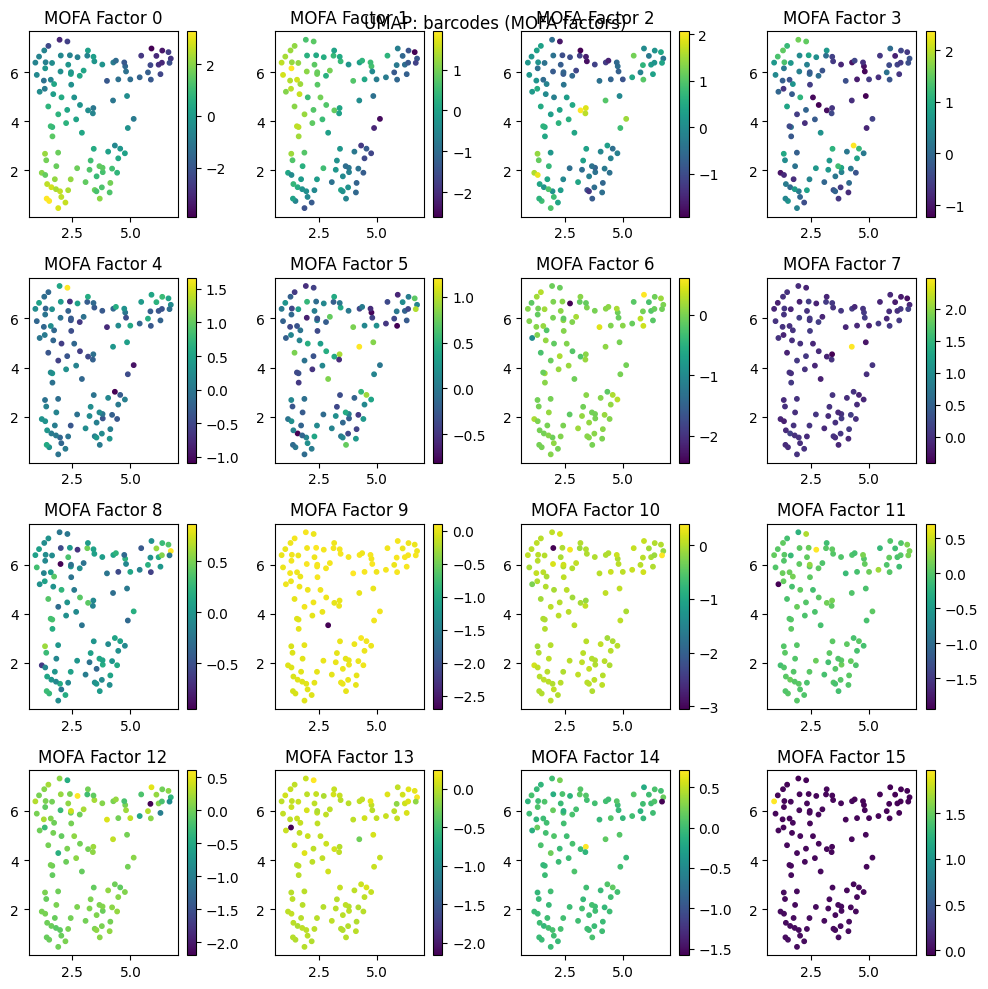

In [69]:
from umap import UMAP
k = Z.shape[1]
Z = ent.model.getExpectations()["Z"]["E"]

X_latent_umap = UMAP(
    n_neighbors=15,
    min_dist=0.3,
    random_state=0
).fit_transform(Z)

from sklearn.cluster import KMeans

clusts = KMeans(n_clusters=k, random_state=0).fit_predict(Z)

import seaborn as sb
import matplotlib.pyplot as plt

sb.scatterplot(
    x=X_latent_umap[:, 0],
    y=X_latent_umap[:, 1],
    hue=clusts
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("Clone clusters: latent UMAP")
plt.show()

import matplotlib.pyplot as plt

n_factors = Z.shape[1]

plt.figure(figsize=(10, 10))

for i in range(min(n_factors, 16)):
    plt.subplot(4, 4, i+1)

    sc = plt.scatter(
        X_latent_umap[:, 0],
        X_latent_umap[:, 1],
        c=Z[:, i],
        cmap="viridis",
        s=10
    )

    plt.colorbar(sc)
    plt.title(f"MOFA Factor {i}")

plt.tight_layout()
plt.suptitle("UMAP: barcodes (MOFA factors)")
plt.show()

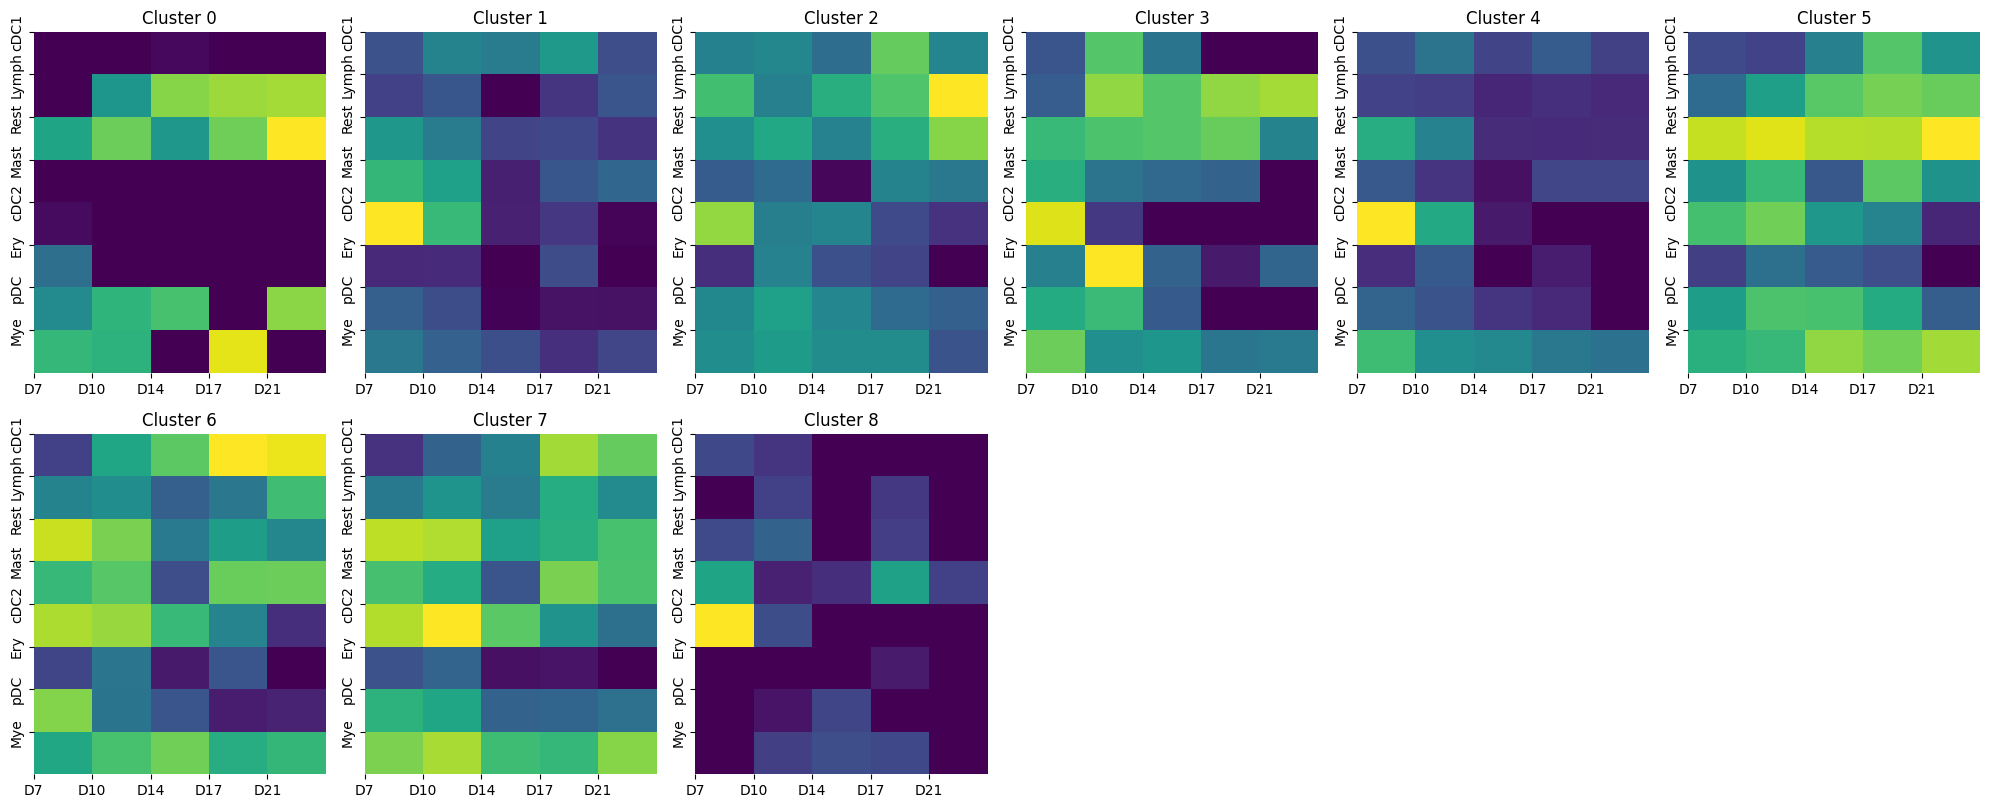

In [70]:
Z = ent.model.getExpectations()["Z"]["E"]      # (112 × K)
W = ent.model.getExpectations()["W"]          # dict per view
X_lineage = X_bc  # (112, 5, 8)
from sklearn.cluster import KMeans

clusts = KMeans(n_clusters=9, random_state=0).fit_predict(Z)
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize=(20, 20))

for cluster_idx in range(len(np.unique(clusts))):
    plt.subplot(5, 6, cluster_idx+1)

    avg = X_lineage[clusts == cluster_idx].mean(0)  # (5 × 8)

    sb.heatmap(
        avg.T,
        cmap="viridis",
        cbar=False
    )

    plt.yticks(range(8), celltypes)
    plt.xticks(range(5), timepoints)
    plt.title(f"Cluster {cluster_idx}")

plt.tight_layout()
plt.show()

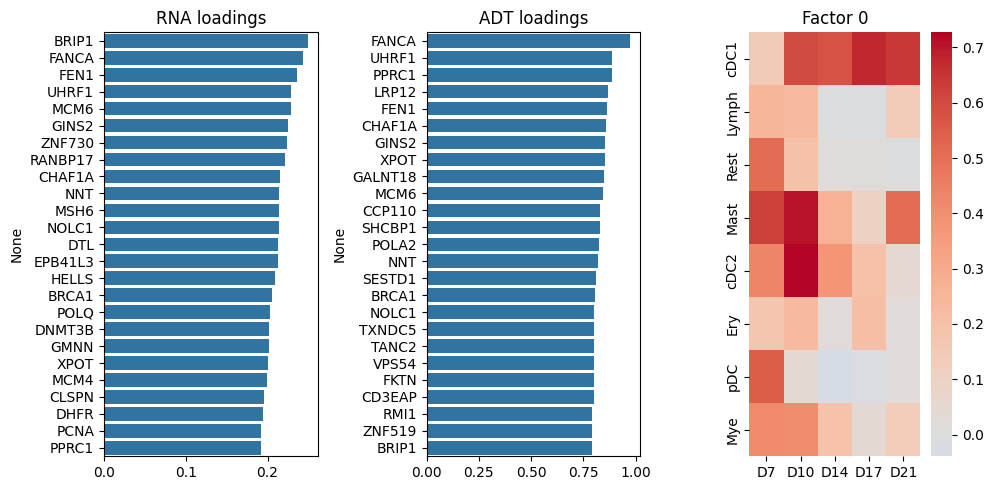

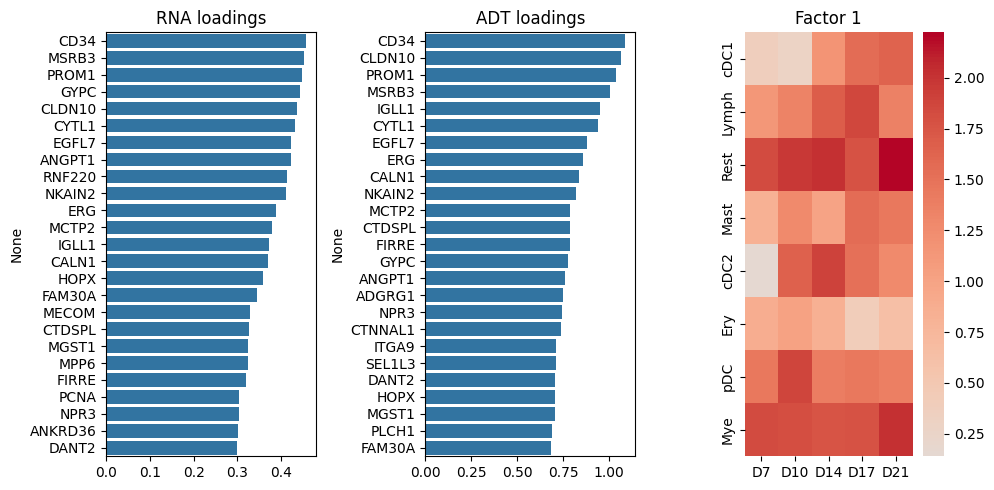

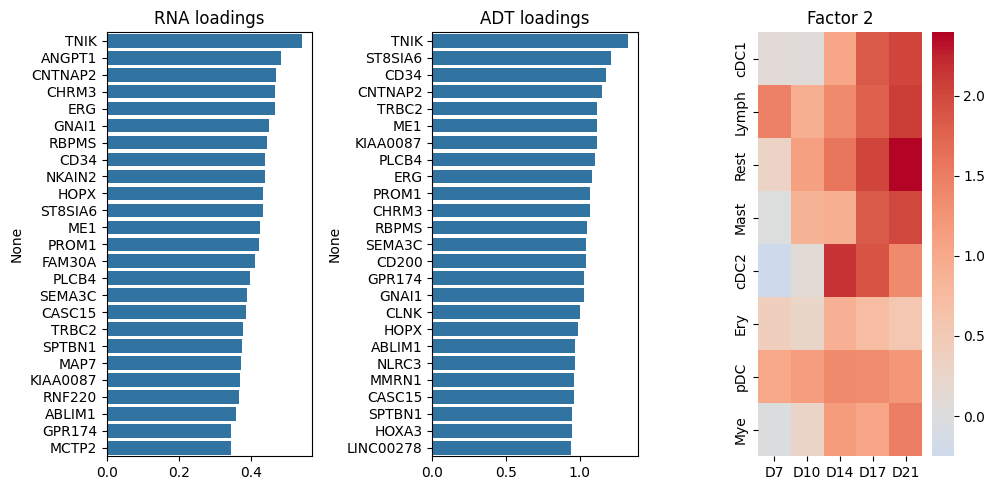

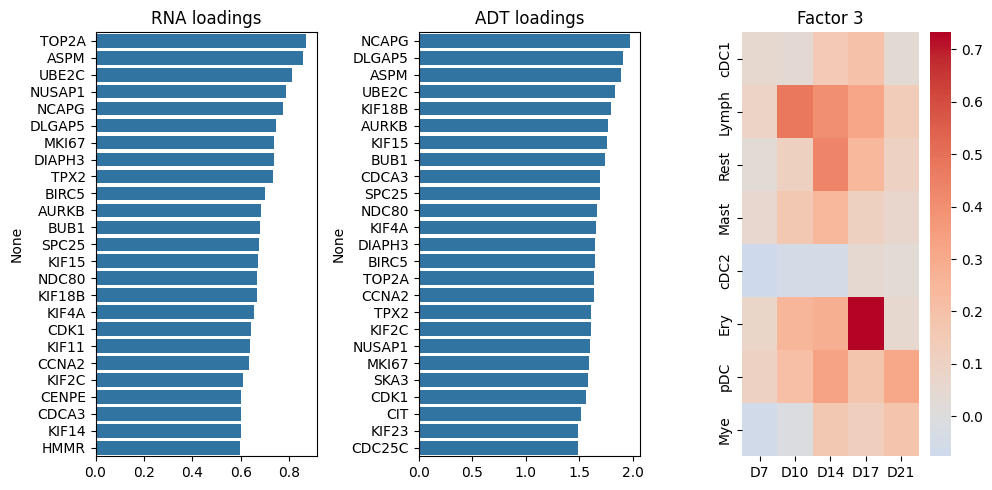

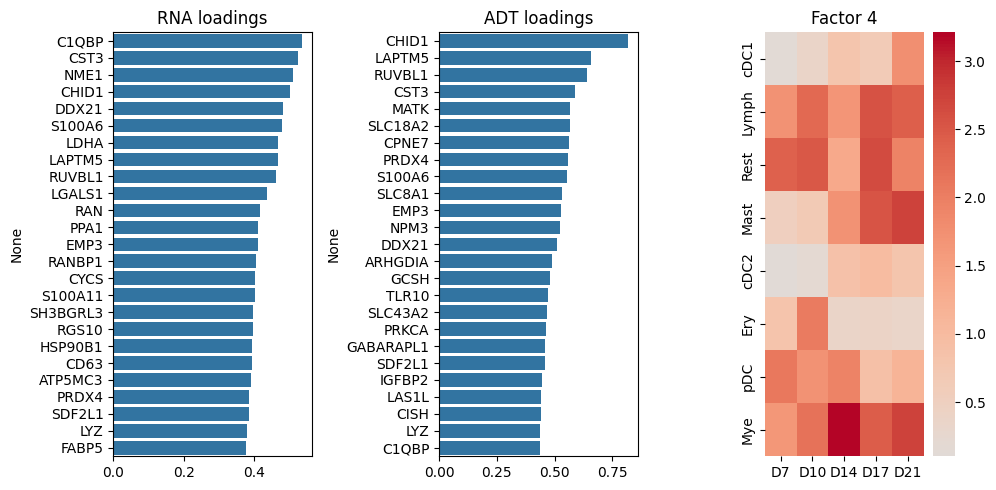

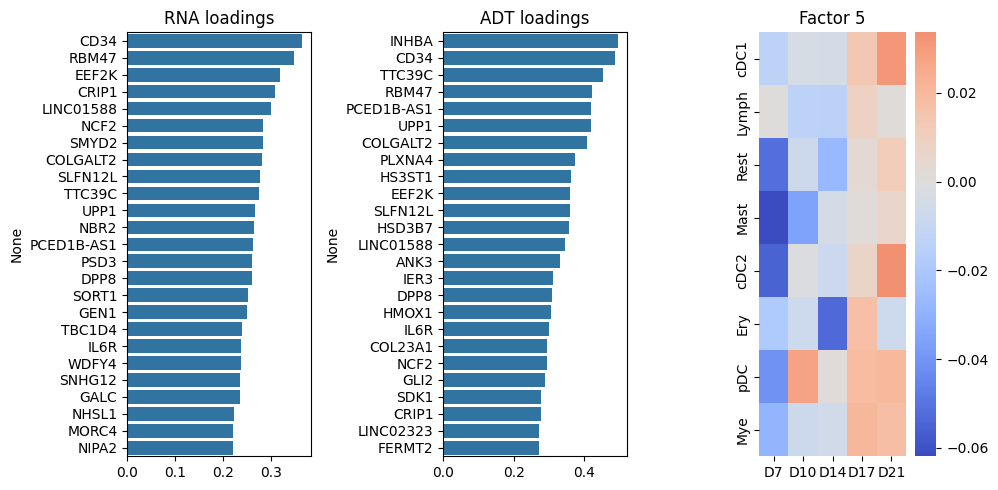

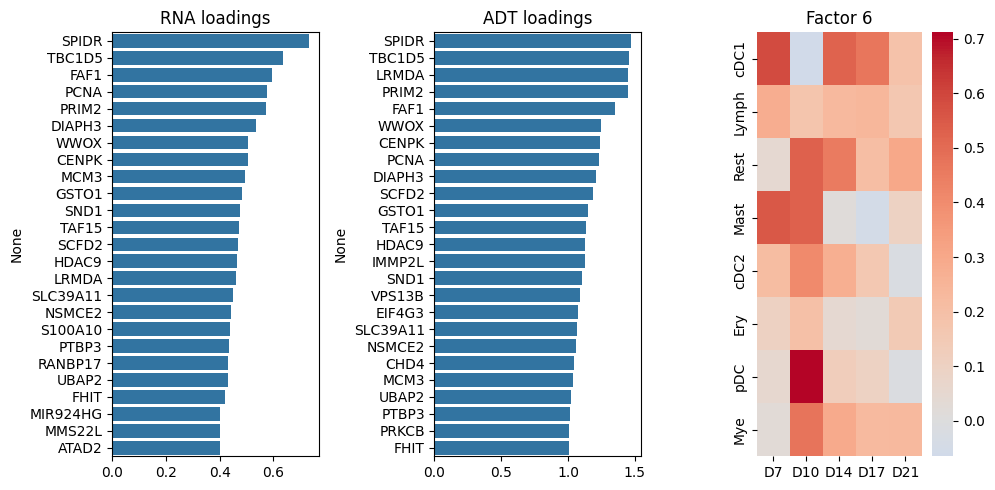

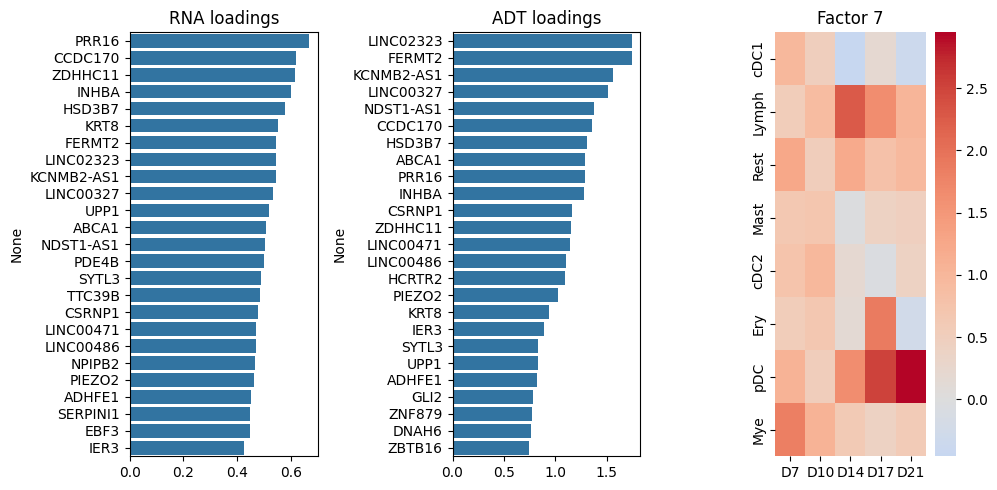

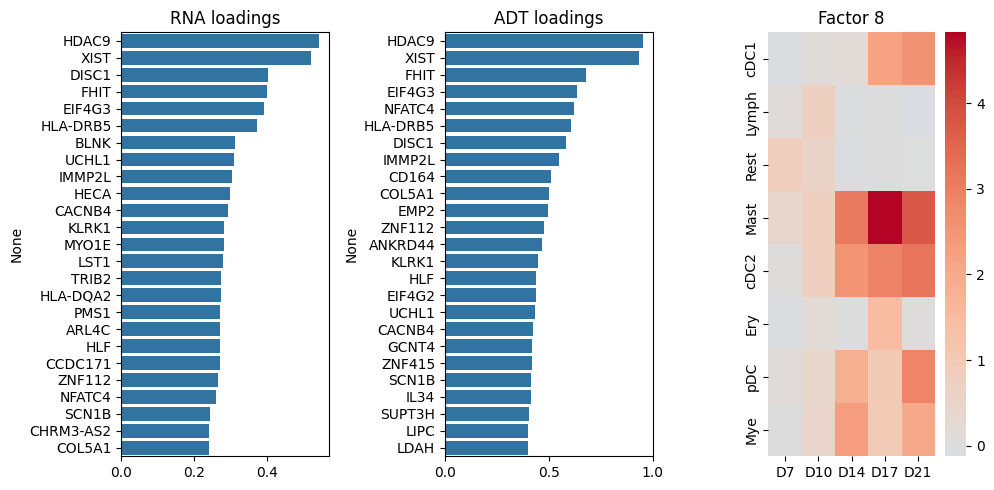

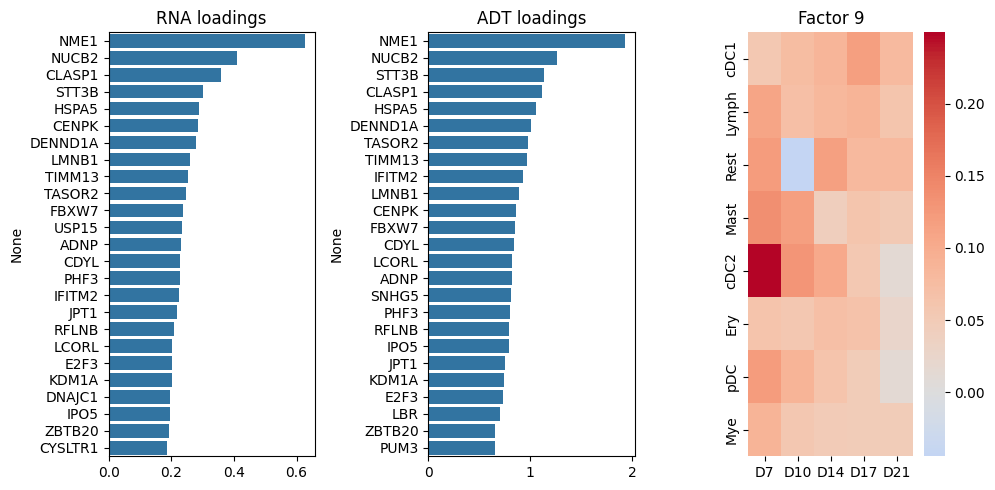

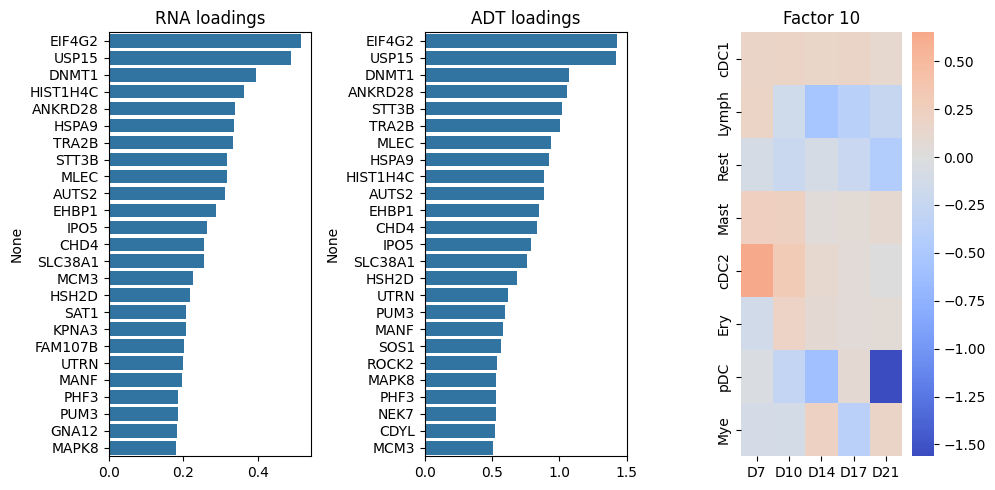

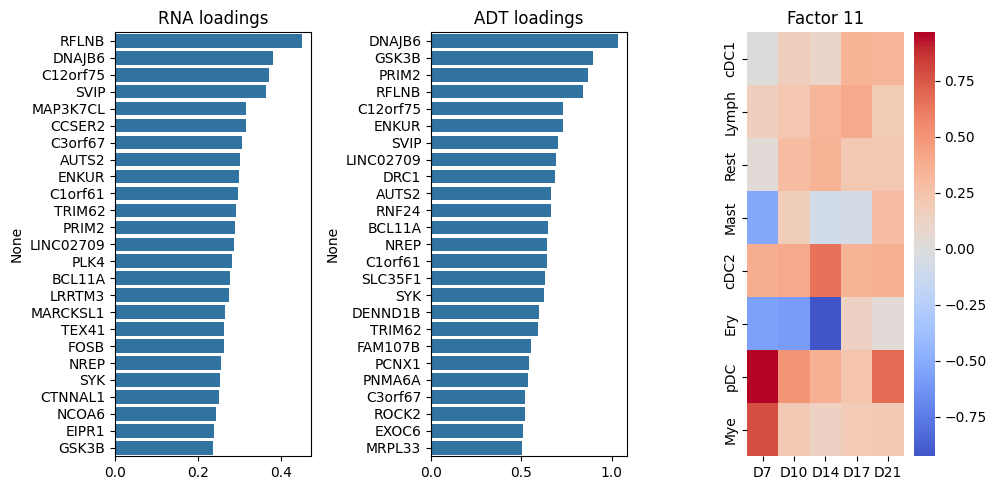

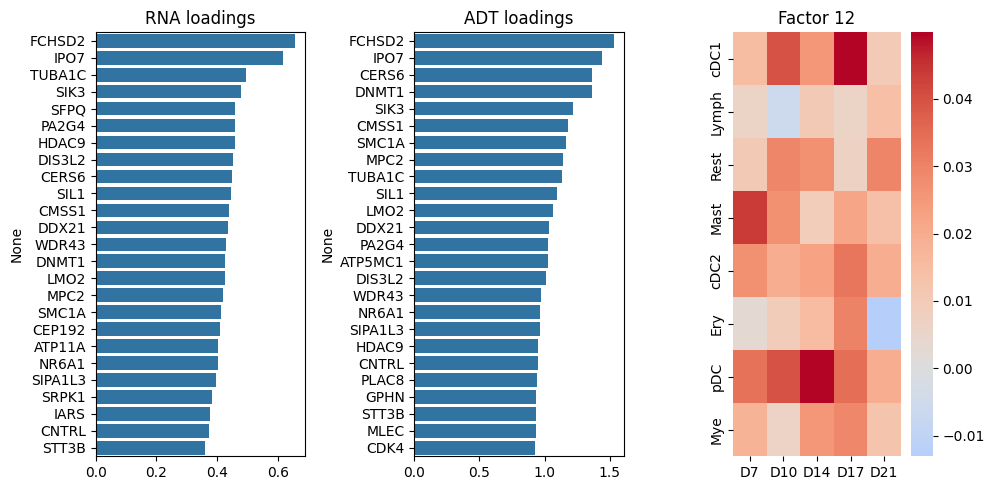

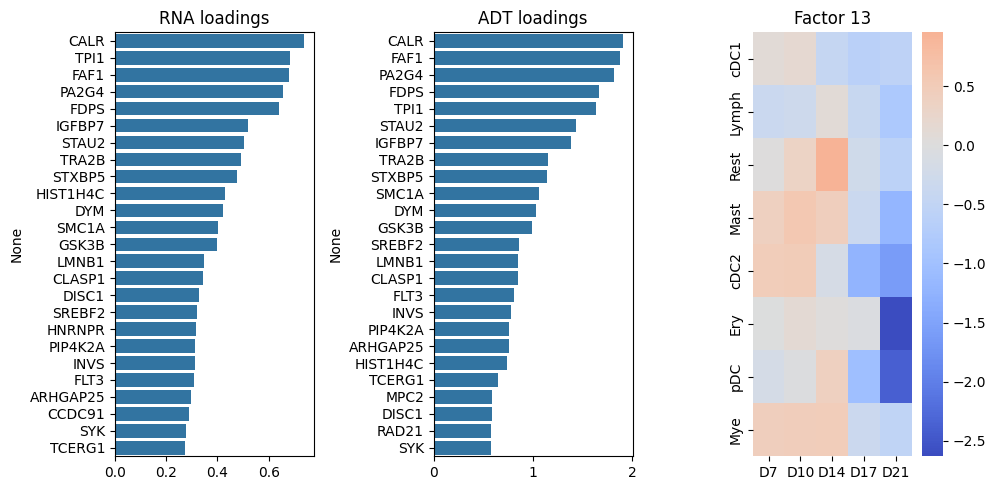

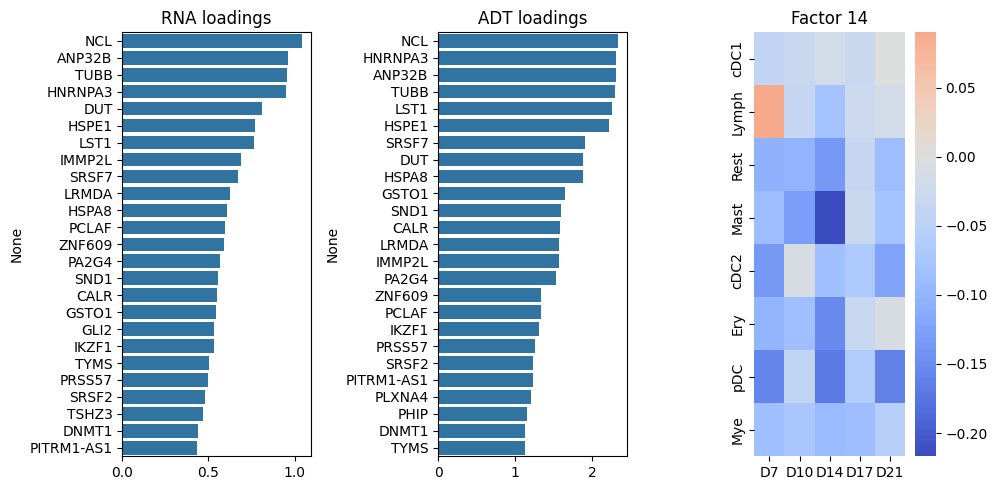

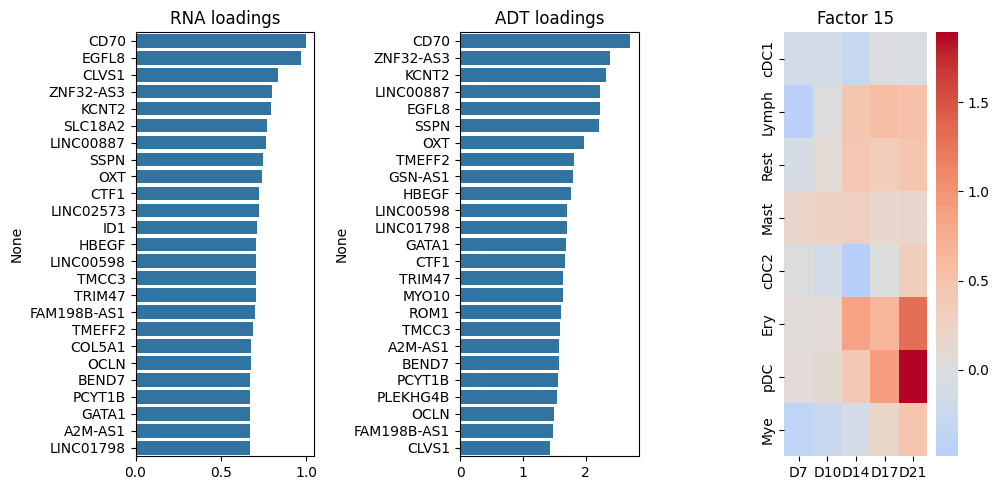

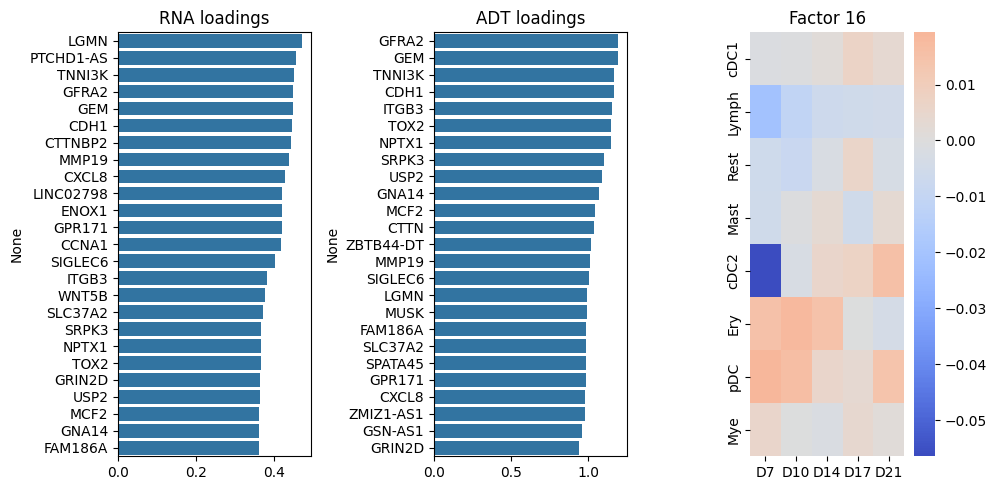

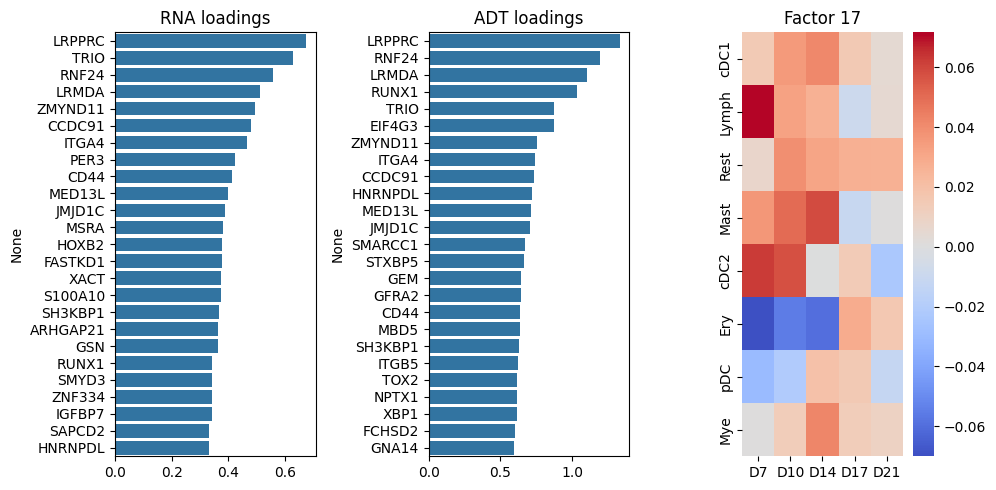

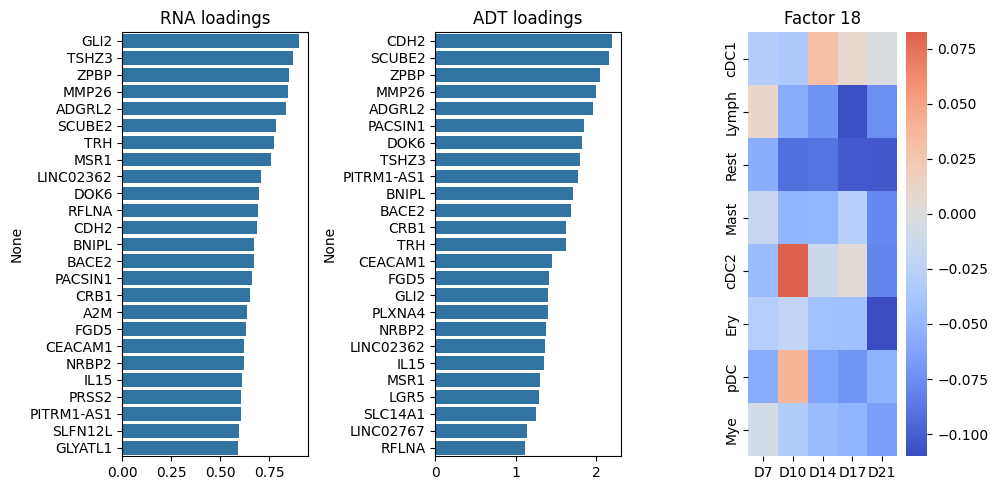

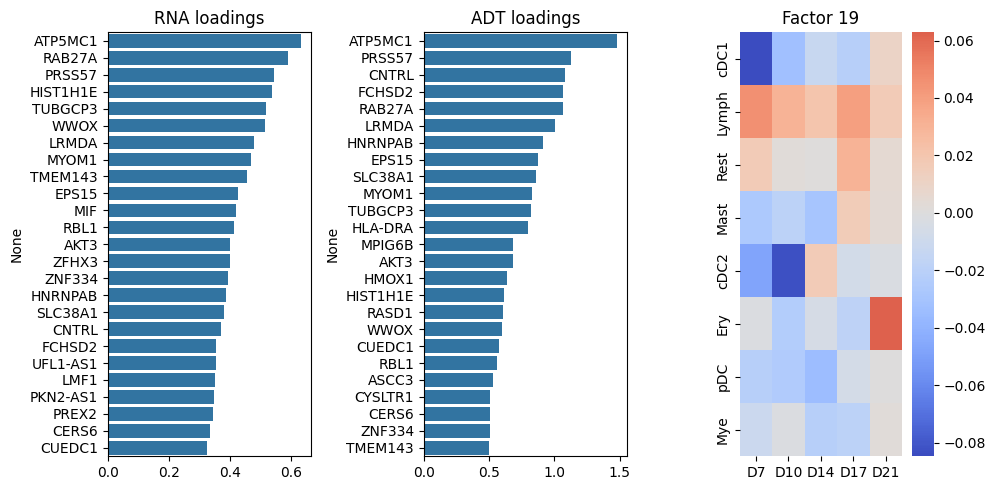

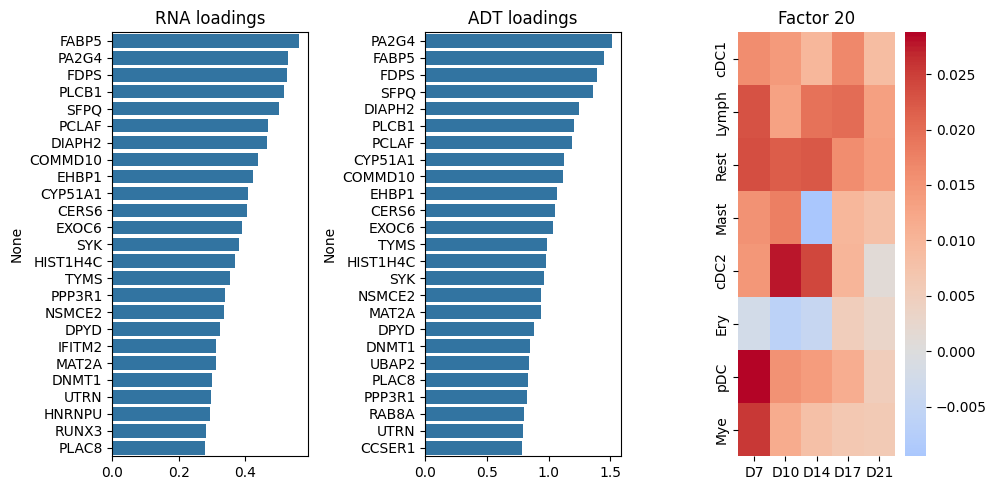

In [71]:
W_rna = W[0]["E"]
W_adt = W[1]["E"]
W_bc  = W[2]["E"]   # flattened 5×8 structure
genes = X_rna.columns
markers = X_adt.columns
n_genes = 25
n_markers = 25

for i in range(Z.shape[1]):

    plt.figure(figsize=(10, 5))

    # -------------------------
    # RNA loadings
    # -------------------------
    plt.subplot(1, 3, 1)

    order = np.argsort(W_rna[:, i])[::-1]
    top_genes = genes[order][:n_genes]
    top_vals = W_rna[order, i][:n_genes]

    sb.barplot(x=top_vals, y=top_genes)
    plt.title("RNA loadings")

    # -------------------------
    # ADT loadings
    # -------------------------
    plt.subplot(1, 3, 2)

    order = np.argsort(W_adt[:, i])[::-1]
    top_markers = markers[order][:n_markers]
    top_vals = W_adt[order, i][:n_markers]

    sb.barplot(x=top_vals, y=top_markers)
    plt.title("ADT loadings")

    # -------------------------
    # lineage structure (5 × 8)
    # -------------------------
    plt.subplot(1, 3, 3)

    lineage = W_bc[:, i].reshape(5, 8)

    sb.heatmap(
        lineage.T,
        cmap="coolwarm",
        center=0,
        xticklabels=timepoints,
        yticklabels=celltypes
    )

    plt.title(f"Factor {i}")

    plt.tight_layout()
    plt.show()

In [72]:
colors = {'cDC1' : '#E66100', 
         'Lymph' : '#1B9E77', 
         'Rest' : '#999999',
         'Mast' : '#8E44AD',
         'cDC2' : '#F1C40F', 
         'Ery' : '#D62728', 
         'pDC' : '#17BECF', 
         'Mye' : '#1F77B4'}

In [73]:
import matplotlib
cmaps = {name : matplotlib.colors.LinearSegmentedColormap.from_list(name, [(1, 1, 1), matplotlib.colors.hex2color(c)]) for (name, c) in colors.items()}

In [74]:
import numpy as np

def plot_multicolor(ax, data):
    vmax = data.max()
    for i, name in enumerate(celltypes):
        cmap = cmaps[name]
        masked_data = np.ma.masked_array(
            data, 
            mask=np.ones_like(data, dtype=bool)
        )
        masked_data.mask[i, :] = False  # Unmask only the current row
        im = ax.imshow(masked_data, cmap=cmap, aspect='auto', extent=[0, data.shape[1], data.shape[0], 0], vmin = 0, vmax = vmax)
    for i, name in enumerate(['Rest']):
        cmap = cmaps[name]
        # Create a scalar mappable with the colormap for the colorbar
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=0, vmax=vmax))
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation='vertical')
        # cbar.ax.set_title(name)
        cbar.ax.set_title("Contribution")
        cbar.ax.set_ylim(0, vmax)

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import os

W = ent.model.getExpectations()["W"]
W_bc = W[2]["E"]   # lineage view (112 features → 5×8 structure)

k = W_bc.shape[1]

os.makedirs("figures_jul2025", exist_ok=True)

for i in range(k):
    fig = plt.figure(figsize=(4, 4))

    # reshape lineage program (time × celltype)
    data = W_bc[:, i].reshape(len(timepoints), len(celltypes)).T

    ax = plt.gca()

    plot_multicolor(ax, data)

    plt.title(f"MOFA Factor {i}")

    plt.yticks(
        np.arange(len(celltypes)) + 0.5,
        celltypes
    )

    plt.xticks(
        np.arange(len(timepoints)) + 0.5,
        timepoints,
        rotation=45
    )

    plt.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.1)

    # plt.savefig(f"figures_jul2025/factor_{i}.pdf", bbox_inches="tight")
    plt.close()

NEW FIGS TO FIND GENE FROM PAPER

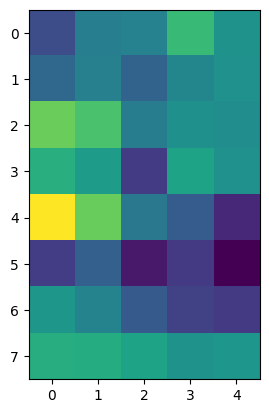

In [76]:
Z = ent.model.getExpectations()["Z"]["E"]
factor_i = i
score = Z[:, factor_i]

# bin clones by factor strength
idx = np.argsort(score)

plt.imshow(X_bc[idx].mean(axis=0).T, cmap="viridis")

In [77]:
W_rna = W[0]["E"]
top_genes = np.argsort(W_rna[:, i])[::-1][:30]
W_adt = W[1]["E"]

In [78]:
print(top_genes)

[2223 3091  280 4265   90 3568 4602 1510  565 2030  693 2615 2380 1657
 3972  577 2279  204 2696  595 4091 1864  451   54 1229 1936 1247 3158
 4122 1216]


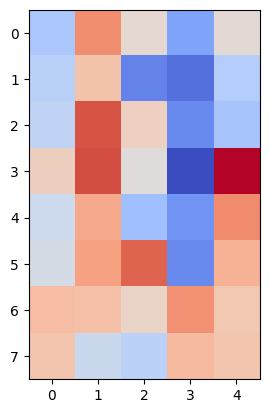

In [79]:
factor_scores = Z[:, i]
fate_profile = X_bc.T @ factor_scores
fate_map = fate_profile.reshape(5, 8)
plt.imshow(fate_map.T, cmap="coolwarm")
umap = UMAP().fit_transform(Z)

rebuild cfm 1-15

In [80]:
from sklearn.cluster import KMeans

cfm_labels = KMeans(n_clusters=15).fit_predict(W_combined)
W_combined = np.vstack([
    W[0]["E"],
    W[1]["E"]
]).T

## myeloid
W_rna[:, cfm1]
Z[:, cfm1]

NameError: name 'cfm1' is not defined

In [ ]:
genes = X_rna.columns
top_idx = np.array([2223, 3091, 280, 4265, 90, 3568, 4602, 1510,
                     565, 2030, 693, 2615, 2380, 1657, 3972, 577,
                     2279, 204, 2696, 595, 4091, 1864, 451, 54,
                     1229, 1936, 1247, 3158, 4122, 1216])

gene_names = genes[top_idx]
print(gene_names)

Index(['FABP5', 'PA2G4', 'FDPS', 'PLCB1', 'SFPQ', 'PCLAF', 'DIAPH2', 'COMMD10',
       'EHBP1', 'CYP51A1', 'CERS6', 'EXOC6', 'SYK', 'HIST1H4C', 'TYMS',
       'PPP3R1', 'NSMCE2', 'DPYD', 'IFITM2', 'MAT2A', 'DNMT1', 'UTRN',
       'HNRNPU', 'RUNX3', 'PLAC8', 'CYCS', 'CCSER1', 'TMPO', 'RAB8A',
       'SEPTIN11'],
      dtype='object')


In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ----------------------------
# 1. Extract MOFA factors
# ----------------------------
Z = ent.model.getExpectations()["Z"]["E"]
W = ent.model.getExpectations()["W"]


genes = X_rna.columns
markers = X_adt.columns

k = Z.shape[1]

# ----------------------------
# 2. Define cell-cycle gene set (expand if needed)
# ----------------------------
cell_cycle_genes = [
    "MSH6", "ESPL1", "CCNG2", "DBF4B", "MCM5",
    "PCNA", "TOP2A", "MKI67"
]

cc_idx = np.array([i for i, g in enumerate(genes) if g in cell_cycle_genes])

# ----------------------------
# 3. Identify cell-cycle factors
# ----------------------------
cc_scores = []

for i in range(k):
    score = np.mean(np.abs(W_rna[cc_idx, i]))
    cc_scores.append(score)

cc_scores = np.array(cc_scores)

# threshold: top 20% = "technical factors"
cc_thresh = np.quantile(cc_scores, 0.80)
is_cc_factor = cc_scores >= cc_thresh

print("Cell-cycle factors:", np.where(is_cc_factor)[0])
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

W = ent.model.getExpectations()["W"]

W_rna = W[0]["E"]
W_adt = W[1]["E"]

genes = X_rna.columns
markers = X_adt.columns

# -------------------------
# 1. Build feature space per MOFA factor (NOT per gene)
# -------------------------
W_combined = np.hstack([W_rna, W_adt])  # genes+markers x factors

W_features = W_combined.T  # factors x features

W_features = StandardScaler().fit_transform(W_features)

# -------------------------
# 2. Cluster FACTORS (not genes)
# -------------------------
n_cfm = 15
cfm_labels = KMeans(n_clusters=n_cfm, random_state=0).fit_predict(W_features)

# -------------------------
# 3. Build CFMs properly
# -------------------------
cfms = []

for c in range(n_cfm):

    factor_ids = np.where(cfm_labels == c)[0]

    gene_scores = np.mean(W_rna[:, factor_ids], axis=1)
    marker_scores = np.mean(W_adt[:, factor_ids], axis=1)

    top_genes = genes[np.argsort(gene_scores)[::-1]]
    top_markers = markers[np.argsort(marker_scores)[::-1]]

    cfms.append({
        "cfm_id": c,
        "genes": list(top_genes),
        "markers": list(top_markers),
        "n_factors": len(factor_ids)
    })

Cell-cycle factors: [ 1  3  6 12 17]


IndexError: index 23 is out of bounds for axis 1 with size 21